# Qwen3 1.7B Eight-Organ Prediction Accuracy - Cleaned Original Process

This notebook keeps the same process as the original script: same repository/data directory, same sorted JSON file names, same model ID, same prompt formatting, same LoRA-wrapped sequence-classification model setup, and same final evaluation flow.


## 1. Runtime and Project Setup


In [1]:
from google.colab import drive
import os
import subprocess
import sys

# Mount Drive and work from /content, same Colab workflow as the original notebook.
drive.mount("/content/drive")
%cd /content

# Keep the original initial cleanup/clone step for parity with the notebook export.
!rm -rf Single_Cell_Aging_Prediction_LLaMA-Factory
!git clone https://github.com/HangYu8123/Single_Cell_Aging_Prediction_LLaMA-Factory.git

os.environ["PJRT_DEVICE"] = "TPU"
os.environ["XLA_USE_BF16"] = "1"
os.environ.setdefault("PT_XLA_DEBUG", "0")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

PYTORCH_VERSION = "2.6.0"

def pip_install(args):
    print("pip", " ".join(args))
    subprocess.check_call([sys.executable, "-m", "pip"] + args)

try:
    import torch
    import torch_xla
    print("torch:", torch.__version__)
    print("torch_xla:", torch_xla.__version__)
except Exception as exc:
    print("Installing torch/torch_xla because import failed:", repr(exc))
    pip_install([
        "-q", "install",
        f"torch=={PYTORCH_VERSION}",
        f"torch_xla[tpu]=={PYTORCH_VERSION}",
        "-f", "https://storage.googleapis.com/libtpu-releases/index.html",
    ])

pip_install([
    "-q", "install", "-U",
    "transformers>=4.45.0",
    "datasets>=2.19.0",
    "scikit-learn>=1.3.0",
    "peft>=0.12.0",
    "evaluate>=0.4.2",
    "matplotlib>=3.8.0",
])

print("Setup done. If torch_xla was just installed, restart the runtime before continuing.")


Mounted at /content/drive
/content
Cloning into 'Single_Cell_Aging_Prediction_LLaMA-Factory'...
remote: Enumerating objects: 25656, done.
remote: Total 25656 (delta 0), reused 0 (delta 0), pack-reused 25656 (from 1)
Receiving objects: 100% (25656/25656), 1.12 GiB | 40.97 MiB/s, done.
Resolving deltas: 100% (18453/18453), done.
Updating files: 100% (511/511), done.
torch: 2.9.0+cpu
torch_xla: 2.9.0
pip -q install -U transformers>=4.45.0 datasets>=2.19.0 scikit-learn>=1.3.0 peft>=0.12.0 evaluate>=0.4.2 matplotlib>=3.8.0
Setup done. If torch_xla was just installed, restart the runtime before continuing.


In [2]:
import torch
import torch_xla
import torch_xla.core.xla_model as xm
import torch_xla.runtime as xr

xr.use_spmd()

# Compatibility patches from the original script.
if not hasattr(torch, "xla"):
    torch.xla = torch_xla

import torch.utils.checkpoint
import torch_xla.utils.checkpoint as xla_ckpt
torch.utils.checkpoint.checkpoint = xla_ckpt.checkpoint

print("torch:", torch.__version__)
print("torch_xla:", torch_xla.__version__)
print("PJRT device:", os.environ.get("PJRT_DEVICE"))
print("Global runtime device count:", xr.global_runtime_device_count())
print("XLA devices:", xm.get_xla_supported_devices())
print("Current XLA device:", torch_xla.device())


torch: 2.9.0+cpu
torch_xla: 2.9.0
PJRT device: TPU
Global runtime device count: 1
XLA devices: ['xla:0']
Current XLA device: xla:0


In [3]:
# Same repository/data location used by the original script for the sorted JSON files.
REPO_URL = "https://github.com/Ha-ya/Single_Cell_Aging_Prediction_LLaMA-Factory.git"
TARGET_DIR = "/content/Single_Cell_Aging_Prediction_LLaMA-Factory"

if not os.path.exists(TARGET_DIR):
    subprocess.check_call(["git", "clone", REPO_URL, TARGET_DIR])
else:
    print("Repo already exists:", TARGET_DIR)

DATA_DIR = f"{TARGET_DIR}/data"
print("DATA_DIR:", DATA_DIR)


Repo already exists: /content/Single_Cell_Aging_Prediction_LLaMA-Factory
DATA_DIR: /content/Single_Cell_Aging_Prediction_LLaMA-Factory/data


## 2. Configuration


In [4]:
import glob
import inspect
import json
import math
import os
import random
import re

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch_xla
import torch_xla.core.xla_model as xm
import torch_xla.runtime as xr
from datasets import Dataset, DatasetDict, load_dataset
from peft import LoraConfig, get_peft_model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainerCallback,
    TrainingArguments,
)
from transformers.trainer_utils import EvalPrediction

MODEL_ID = "Ha-ya/QWEN3-1.7B-EIGHT-ORGANS-EXTENDED-1K"

TRAIN_PARTS = list(range(1, 11))
EVAL_PART = 11
MAX_LENGTH = 1024
NUM_EPOCHS = 2
LR = 1e-4
WEIGHT_DECAY = 0.0
WARMUP_RATIO = 0.03
GLOBAL_TRAIN_BS = 128
GLOBAL_EVAL_BS = 128
GRAD_ACCUM_STEPS = 1
SEED = 42
DTYPE = torch.bfloat16

OUT_DIR = "/content/qwen3_bladder_tpu_out"
out_dir = OUT_DIR
SAVE_STEPS = 1000
EVAL_STEPS = 10000

LABEL2ID = {"1m": 0, "3m": 1, "18m": 2, "24m": 3, "30m": 4}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
LABEL_SUFFIX = "Answer with exactly one label from {1m, 3m, 18m, 24m, 30m}."

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(SEED)

xr.use_spmd()
num_devices = xr.global_runtime_device_count()
print("SPMD devices:", num_devices, "current:", torch_xla.device())

if GLOBAL_TRAIN_BS % num_devices != 0:
    raise ValueError(f"GLOBAL_TRAIN_BS ({GLOBAL_TRAIN_BS}) must be divisible by num_devices ({num_devices}) in SPMD.")
if GLOBAL_EVAL_BS % num_devices != 0:
    raise ValueError(f"GLOBAL_EVAL_BS ({GLOBAL_EVAL_BS}) must be divisible by num_devices ({num_devices}) in SPMD.")

print("MODEL_ID:", MODEL_ID)
print("DTYPE:", DTYPE)
print("Files found:", len(glob.glob(f"{DATA_DIR}/*.json")))
print("Example files:", sorted(glob.glob(f"{DATA_DIR}/*.json"))[:5])


SPMD devices: 1 current: xla:0
MODEL_ID: Ha-ya/QWEN3-1.7B-EIGHT-ORGANS-EXTENDED-1K
DTYPE: torch.bfloat16
Files found: 299
Example files: ['/content/Single_Cell_Aging_Prediction_LLaMA-Factory/data/bladder_cell_data_part_1.json', '/content/Single_Cell_Aging_Prediction_LLaMA-Factory/data/bladder_cell_data_part_10.json', '/content/Single_Cell_Aging_Prediction_LLaMA-Factory/data/bladder_cell_data_part_10_sorted_noorgan.json', '/content/Single_Cell_Aging_Prediction_LLaMA-Factory/data/bladder_cell_data_part_11.json', '/content/Single_Cell_Aging_Prediction_LLaMA-Factory/data/bladder_cell_data_part_11_sorted_noorgan.json']


/usr/local/lib/python3.12/dist-packages/torch_xla/runtime.py:201: UserWarning: XLA_USE_SPMD is being deprecated. Use torch_xla.runtime.use_spmd() without setting XLA_USE_SPMD env-var.
  warnings.warn("XLA_USE_SPMD is being deprecated. "


## 3. Load the Same Sorted JSON Files


In [5]:
train_files_bladder = [f"{DATA_DIR}/sorted/bladder_cell_data_part_{i}_sorted.json" for i in TRAIN_PARTS]
train_files_brain = [f"{DATA_DIR}/sorted/cell_data_part_{i}_sorted.json" for i in TRAIN_PARTS]
train_files_bone = [f"{DATA_DIR}/sorted/bone-marrow_cell_data_part_{i}_sorted.json" for i in TRAIN_PARTS]
train_files_limb = [f"{DATA_DIR}/sorted/limb-muscle_cell_data_part_{i}_sorted.json" for i in TRAIN_PARTS]
train_files_kidney = [f"{DATA_DIR}/sorted/kidney_cell_data_part_{i}_sorted.json" for i in TRAIN_PARTS]
train_file_liver = [f"{DATA_DIR}/sorted/liver_cell_data_part_{i}_sorted.json" for i in TRAIN_PARTS]
train_files_lung = [f"{DATA_DIR}/sorted/lung_cell_data_part_{i}_sorted.json" for i in TRAIN_PARTS]
train_files_heart = [f"{DATA_DIR}/sorted/heart_cell_data_part_{i}_sorted.json" for i in TRAIN_PARTS]

train_files = (
    train_files_bladder
    + train_files_brain
    + train_files_bone
    + train_files_limb
    + train_files_kidney
    + train_file_liver
    + train_files_lung
    + train_files_heart
)

eval_files_bladder = [f"{DATA_DIR}/sorted/bladder_cell_data_part_{EVAL_PART}_sorted.json"]
eval_files_brain = [f"{DATA_DIR}/sorted/cell_data_part_{EVAL_PART}_sorted.json"]
eval_files_bone = [f"{DATA_DIR}/sorted/bone-marrow_cell_data_part_{EVAL_PART}_sorted.json"]
eval_files_limb = [f"{DATA_DIR}/sorted/limb-muscle_cell_data_part_{EVAL_PART}_sorted.json"]
eval_files_kidney = [f"{DATA_DIR}/sorted/kidney_cell_data_part_{EVAL_PART}_sorted.json"]
eval_files_liver = [f"{DATA_DIR}/sorted/liver_cell_data_part_{EVAL_PART}_sorted.json"]
eval_files_lung = [f"{DATA_DIR}/sorted/lung_cell_data_part_{EVAL_PART}_sorted.json"]
eval_files_heart = [f"{DATA_DIR}/sorted/heart_cell_data_part_{EVAL_PART}_sorted.json"]

eval_files = (
    eval_files_bladder
    + eval_files_brain
    + eval_files_bone
    + eval_files_limb
    + eval_files_kidney
    + eval_files_liver
    + eval_files_lung
    + eval_files_heart
)

print("Eval file:", eval_files[0])

def load_json_dataset(files):
    try:
        return load_dataset("json", data_files=files, split="train")
    except Exception as exc:
        print("load_dataset(json) failed; falling back to manual JSON load. Error:", exc)
        rows = []
        for fp in files:
            with open(fp, "r") as handle:
                rows.extend(json.load(handle))
        return Dataset.from_list(rows)

train_ds = load_json_dataset(train_files)
eval_ds = load_json_dataset(eval_files)
bladder_ds = load_json_dataset(eval_files_bladder)
brain_ds = load_json_dataset(eval_files_brain)
bone_ds = load_json_dataset(eval_files_bone)
limb_ds = load_json_dataset(eval_files_limb)
kidney_ds = load_json_dataset(eval_files_kidney)
liver_ds = load_json_dataset(eval_files_liver)
lung_ds = load_json_dataset(eval_files_lung)
heart_ds = load_json_dataset(eval_files_heart)

raw = DatasetDict({
    "train": train_ds,
    "validation": eval_ds,
    "brain": brain_ds,
    "bladder": bladder_ds,
    "bone": bone_ds,
    "limb": limb_ds,
    "kidney": kidney_ds,
    "liver": liver_ds,
    "lung": lung_ds,
    "heart": heart_ds,
})

print(raw)
print("Columns:", raw["validation"].column_names)
print("Example output label:", raw["validation"][0].get("output"))


Eval file: /content/Single_Cell_Aging_Prediction_LLaMA-Factory/data/sorted/bladder_cell_data_part_11_sorted.json


Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

...

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 85675
    })
    validation: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 8564
    })
    brain: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 1741
    })
    bladder: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 692
    })
    bone: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 2288
    })
    limb: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 1581
    })
    kidney: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 660
    })
    liver: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 350
    })
    lung: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 817
    })
    heart: Dataset({
        features: 

## 4. Prompt Formatting and Tokenization

This intentionally uses the original prompt format. It does not re-sort or truncate genes before tokenization.


In [6]:
def format_text(example):
    instruction = (example.get("instruction") or "").strip()
    inp = (example.get("input") or "").strip()
    label = (example.get("output") or "").strip()

    if label not in LABEL2ID:
        raise ValueError(f"Unexpected label: {label}")

    text = instruction + "\n\n" + inp + "\n\n" + LABEL_SUFFIX
    return {"text": text, "label": LABEL2ID[label]}

raw = raw.map(format_text, remove_columns=raw["train"].column_names)
print(raw["train"][0])

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

if tokenizer.bos_token_id is None and tokenizer.eos_token_id is not None:
    tokenizer.bos_token = tokenizer.eos_token

def tok_fn(batch):
    out = tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding="max_length",
    )
    out["labels"] = batch["label"]
    return out

tok = raw.map(tok_fn, batched=True, remove_columns=raw["train"].column_names)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, pad_to_multiple_of=128)

print(tok)
print(tok["validation"][0].keys())


Map:   0%|          | 0/85675 [00:00<?, ? examples/s]

Map:   0%|          | 0/8564 [00:00<?, ? examples/s]

Map:   0%|          | 0/1741 [00:00<?, ? examples/s]

Map:   0%|          | 0/692 [00:00<?, ? examples/s]

Map:   0%|          | 0/2288 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/660 [00:00<?, ? examples/s]

Map:   0%|          | 0/350 [00:00<?, ? examples/s]

Map:   0%|          | 0/817 [00:00<?, ? examples/s]

Map:   0%|          | 0/435 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 85675
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 8564
    })
    brain: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1741
    })
    bladder: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 692
    })
    bone: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 2288
    })
    limb: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1581
    })
    kidney: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 660
    })
    liver: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 350
    })
    lung: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
     

## 5. Model, LoRA, and Trainer Setup


In [7]:
def guess_lora_targets(model: torch.nn.Module):
    common = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
    present = set()
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Linear):
            for target_name in common:
                if name.endswith(target_name):
                    present.add(target_name)
    if not present:
        present = {"q_proj", "v_proj"}
    return sorted(present)

def infer_transformer_layer_cls_to_wrap(model: torch.nn.Module):
    base = getattr(model, "base_model", model)
    base = getattr(base, "model", base)

    candidate_getters = [
        ("model.layers", lambda m: m.model.layers),
        ("model.model.layers", lambda m: m.model.model.layers),
        ("transformer.h", lambda m: m.transformer.h),
        ("gpt_neox.layers", lambda m: m.gpt_neox.layers),
        ("layers", lambda m: m.layers),
    ]
    for desc, getter in candidate_getters:
        try:
            layers = getter(base)
            if hasattr(layers, "__len__") and len(layers) > 0:
                cls_name = layers[0].__class__.__name__
                print(f"Detected transformer layer via {desc}: {cls_name}")
                return [cls_name]
        except Exception:
            pass

    for name, module in base.named_modules():
        if isinstance(module, torch.nn.ModuleList) and len(module) > 0:
            cls_name = module[0].__class__.__name__
            if re.search(r"(Layer|Block|DecoderLayer|Transformer)", cls_name):
                print(f"Heuristic transformer layer: {cls_name} (from {name})")
                return [cls_name]

    raise RuntimeError("Could not infer transformer layer class for FSDP auto-wrap.")

def filter_kwargs_for_callable(fn, kwargs: dict):
    params = set(inspect.signature(fn).parameters.keys())
    return {key: value for key, value in kwargs.items() if key in params}

model_kwargs = {
    "num_labels": len(LABEL2ID),
    "id2label": ID2LABEL,
    "label2id": LABEL2ID,
    "trust_remote_code": True,
}

sig = inspect.signature(AutoModelForSequenceClassification.from_pretrained)
if "dtype" in sig.parameters:
    model_kwargs["dtype"] = DTYPE
else:
    model_kwargs["torch_dtype"] = DTYPE

model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID, **model_kwargs)
model.config.use_cache = False
model.config.pad_token_id = tokenizer.pad_token_id
if getattr(model.config, "bos_token_id", None) is None and tokenizer.bos_token_id is not None:
    model.config.bos_token_id = tokenizer.bos_token_id
if hasattr(model, "generation_config") and getattr(model.generation_config, "bos_token_id", None) is None:
    model.generation_config.bos_token_id = tokenizer.bos_token_id

lora_targets = guess_lora_targets(model)
lora_targets = sorted(set(lora_targets + ["embed_tokens"]))
print("LoRA target_modules:", lora_targets)

lora_config = LoraConfig(
    r=32,
    lora_alpha=64,
    lora_dropout=0.05,
    bias="none",
    task_type="SEQ_CLS",
    target_modules=lora_targets,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

model.config.use_cache = False
if hasattr(model, "gradient_checkpointing_enable"):
    try:
        model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": True})
    except TypeError:
        model.gradient_checkpointing_enable()
        if hasattr(model, "_gradient_checkpointing_kwargs"):
            model._gradient_checkpointing_kwargs = {"use_reentrant": True}

fsdp_layer_cls = infer_transformer_layer_cls_to_wrap(model)
fsdp_config = {"xla": True, "xla_fsdp_v2": True}
print("FSDP layer classes:", fsdp_layer_cls)


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.53G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

LoRA target_modules: ['down_proj', 'embed_tokens', 'gate_proj', 'k_proj', 'o_proj', 'q_proj', 'up_proj', 'v_proj']
trainable params: 40,522,048 || all params: 1,807,134,016 || trainable%: 2.2423
Detected transformer layer via model.layers: Qwen3DecoderLayer
FSDP layer classes: ['Qwen3DecoderLayer']


In [8]:
def compute_metrics(p: EvalPrediction):
    logits = p.predictions
    labels = p.label_ids
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }

SMALL_EVAL_SIZE = 512
small_eval_dataset = tok["validation"].shuffle(seed=SEED).select(
    range(min(SMALL_EVAL_SIZE, len(tok["validation"])))
)

train_dataset_size = len(tok["train"])
effective_batch_size = GLOBAL_TRAIN_BS * GRAD_ACCUM_STEPS
steps_per_epoch = max(1, train_dataset_size // effective_batch_size)
steps_per_mid = max(1, steps_per_epoch // 8)

print(f"Train samples: {train_dataset_size}")
print(f"Effective batch size: {effective_batch_size}")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Steps per mid-eval: {steps_per_mid}")

class MidEvalCallback(TrainerCallback):
    def __init__(self, eval_dataset, every_n_steps: int):
        self.eval_dataset = eval_dataset
        self.every_n_steps = every_n_steps
        self.trainer = None

    def on_step_end(self, args, state, control, **kwargs):
        if state.global_step <= 0 or state.global_step % self.every_n_steps != 0:
            return control
        if getattr(args, "eval_steps", None) and args.eval_steps > 0 and state.global_step % args.eval_steps == 0:
            return control
        if getattr(args, "save_steps", None) and args.save_steps > 0 and state.global_step % args.save_steps == 0:
            return control

        metrics = self.trainer.evaluate(eval_dataset=self.eval_dataset, metric_key_prefix="mid_eval")
        self.trainer.log(metrics)

        if getattr(args, "process_index", 0) == 0:
            keys = [key for key in ["mid_eval_loss", "mid_eval_accuracy", "mid_eval_macro_f1"] if key in metrics]
            msg = " | ".join(f"{key}={metrics[key]:.6f}" for key in keys) if keys else str(metrics)
            print(f"\nMid-eval @ step {state.global_step}: {msg}\n")
        return control

class XlaSyncEverySubstepCallback(TrainerCallback):
    def on_substep_end(self, args, state, control, **kwargs):
        torch_xla.sync()
        return control

ta_kwargs = {
    "output_dir": out_dir,
    "num_train_epochs": NUM_EPOCHS,
    "learning_rate": LR,
    "warmup_ratio": WARMUP_RATIO,
    "weight_decay": WEIGHT_DECAY,
    "optim": "adafactor",
    "per_device_train_batch_size": GLOBAL_TRAIN_BS,
    "per_device_eval_batch_size": GLOBAL_EVAL_BS,
    "gradient_accumulation_steps": GRAD_ACCUM_STEPS,
    "bf16": True,
    "logging_steps": 512,
    "save_strategy": "steps",
    "save_steps": SAVE_STEPS,
    "eval_strategy": "steps",
    "eval_steps": EVAL_STEPS,
    "dataloader_drop_last": True,
    "dataloader_pin_memory": False,
    "dataloader_num_workers": 0,
    "save_safetensors": False,
    "remove_unused_columns": False,
    "report_to": "none",
    "seed": SEED,
}

ta_sig_params = set(inspect.signature(TrainingArguments.__init__).parameters.keys())
if "eval_strategy" in ta_kwargs and "eval_strategy" not in ta_sig_params and "evaluation_strategy" in ta_sig_params:
    ta_kwargs["evaluation_strategy"] = ta_kwargs.pop("eval_strategy")

ta_kwargs = filter_kwargs_for_callable(TrainingArguments.__init__, ta_kwargs)
args = TrainingArguments(**ta_kwargs)
print("TrainingArguments keys used:", sorted(ta_kwargs.keys()))

trainer_kwargs = {
    "model": model,
    "args": args,
    "train_dataset": tok["train"],
    "eval_dataset": tok["validation"],
    "data_collator": data_collator,
    "compute_metrics": compute_metrics,
}

trainer_init_params = set(inspect.signature(Trainer.__init__).parameters.keys())
if "processing_class" in trainer_init_params:
    trainer_kwargs["processing_class"] = tokenizer
elif "tokenizer" in trainer_init_params:
    trainer_kwargs["tokenizer"] = tokenizer

trainer = Trainer(**trainer_kwargs)
trainer.add_callback(XlaSyncEverySubstepCallback())

mid_cb = MidEvalCallback(eval_dataset=small_eval_dataset, every_n_steps=steps_per_mid)
mid_cb.trainer = trainer
trainer.add_callback(mid_cb)

print("Trainer ready.")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Train samples: 85675
Effective batch size: 128
Steps per epoch: 669
Steps per mid-eval: 83
TrainingArguments keys used: ['bf16', 'dataloader_drop_last', 'dataloader_num_workers', 'dataloader_pin_memory', 'eval_steps', 'eval_strategy', 'gradient_accumulation_steps', 'learning_rate', 'logging_steps', 'num_train_epochs', 'optim', 'output_dir', 'per_device_eval_batch_size', 'per_device_train_batch_size', 'remove_unused_columns', 'report_to', 'save_steps', 'save_strategy', 'seed', 'warmup_ratio', 'weight_decay']
Trainer ready.


## 6. Evaluation Helpers


In [9]:
def _get_logits(predictions):
    if isinstance(predictions, (tuple, list)):
        return predictions[0]
    return predictions

labels_sorted = sorted(ID2LABEL.keys())
label_names = [ID2LABEL[i] for i in labels_sorted]
_ID_CANDIDATES = ["id", "idx", "guid", "example_id", "uid", "record_id"]

def _try_get_indices_from__indices(subset_ds):
    idx_tbl = getattr(subset_ds, "_indices", None)
    if idx_tbl is None:
        return None
    try:
        col_names = getattr(idx_tbl, "column_names", None)
        if col_names and len(col_names) > 0:
            col = idx_tbl.column(col_names.index("indices") if "indices" in col_names else 0)
            return np.asarray(col.to_pylist(), dtype=np.int64)
    except Exception:
        pass
    try:
        if hasattr(idx_tbl, "to_pydict"):
            idx_dict = idx_tbl.to_pydict()
            if "indices" in idx_dict:
                return np.asarray(idx_dict["indices"], dtype=np.int64)
            if idx_dict:
                first_key = list(idx_dict.keys())[0]
                return np.asarray(idx_dict[first_key], dtype=np.int64)
    except Exception:
        pass
    return None

def _pick_id_column(ds):
    cols = set(getattr(ds, "column_names", []))
    for col in _ID_CANDIDATES:
        if col in cols:
            return col
    return None

def _try_get_indices_from_id_column(subset_ds, parent_ds):
    parent_id_col = _pick_id_column(parent_ds)
    subset_id_col = _pick_id_column(subset_ds)
    if parent_id_col is None or subset_id_col is None or parent_id_col != subset_id_col:
        return None

    try:
        parent_ids = parent_ds[parent_id_col]
        subset_ids = subset_ds[subset_id_col]
    except Exception:
        return None

    id_to_index = {}
    for index, value in enumerate(parent_ids):
        if value not in id_to_index:
            id_to_index[value] = index

    idx = []
    for value in subset_ids:
        if value not in id_to_index:
            return None
        idx.append(id_to_index[value])
    return np.asarray(idx, dtype=np.int64)

def get_subset_indices_in_validation(subset_ds, validation_ds):
    idx = _try_get_indices_from__indices(subset_ds)
    if idx is not None:
        return idx
    return _try_get_indices_from_id_column(subset_ds, validation_ds)

def evaluate_from_arrays(split_name: str, y_true: np.ndarray, logits: np.ndarray, metrics: dict | None = None):
    y_true = np.asarray(y_true).reshape(-1)
    logits = np.asarray(logits)
    y_pred = np.argmax(logits, axis=-1).reshape(-1)

    cm = confusion_matrix(y_true, y_pred, labels=labels_sorted)
    per_label_acc = {}
    for row_i, lab_id in enumerate(labels_sorted):
        denom = cm[row_i, :].sum()
        per_label_acc[ID2LABEL[lab_id]] = float(cm[row_i, row_i] / denom) if denom > 0 else float("nan")

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=labels_sorted,
        target_names=label_names,
        digits=4,
        output_dict=True,
        zero_division=0,
    )

    derived = {
        "accuracy": float(report_dict.get("accuracy", float("nan"))),
        "macro_precision": float(report_dict.get("macro avg", {}).get("precision", float("nan"))),
        "macro_recall": float(report_dict.get("macro avg", {}).get("recall", float("nan"))),
        "macro_f1": float(report_dict.get("macro avg", {}).get("f1-score", float("nan"))),
        "weighted_f1": float(report_dict.get("weighted avg", {}).get("f1-score", float("nan"))),
    }

    overall_metrics = dict(metrics or {})
    overall_metrics[f"final_{split_name}_accuracy"] = derived["accuracy"]
    overall_metrics[f"final_{split_name}_macro_f1"] = derived["macro_f1"]

    return {
        "split": split_name,
        "num_samples": int(len(y_true)),
        "overall_metrics": overall_metrics,
        "derived_metrics": derived,
        "per_label_accuracy_rowwise": per_label_acc,
        "confusion_matrix": {"labels": label_names, "matrix": cm.tolist()},
        "classification_report": report_dict,
    }


In [16]:
from matplotlib.colors import LinearSegmentedColormap
def _extract_overall_acc(metrics: dict, report_dict: dict):
    acc_key = next((key for key in metrics.keys() if key.endswith("accuracy")), None)
    if acc_key is not None and isinstance(metrics.get(acc_key), (int, float)):
        return float(metrics[acc_key])
    if "accuracy" in report_dict and isinstance(report_dict["accuracy"], (int, float)):
        return float(report_dict["accuracy"])
    return float("nan")

def plot_accuracy_f1_recall(split_result: dict, output_dir: str) -> None:
    labels = split_result["confusion_matrix"]["labels"]
    report = split_result["classification_report"]

    recalls = []
    f1s = []
    supports = []
    for label in labels:
        recalls.append(split_result["per_label_accuracy_rowwise"].get(label, float("nan")))
        if label in report:
            f1s.append(float(report[label].get("f1-score", 0.0)))
            supports.append(int(report[label].get("support", 0)))
        else:
            f1s.append(0.0)
            supports.append(0)

    recalls_plot = [0.0 if not np.isfinite(value) else float(value) for value in recalls]
    overall_acc = split_result["derived_metrics"]["accuracy"]
    macro_recall = split_result["derived_metrics"]["macro_recall"]
    macro_f1 = split_result["derived_metrics"]["macro_f1"]

    x = np.arange(len(labels))
    bar_width = 0.36
    inner_gap = 0.025

    plt.figure(figsize=(max(10, 0.7 * len(labels)), 6))
    plt.bar(x - (bar_width / 2 + inner_gap / 2), recalls_plot, bar_width, label="Per-class Recall", color="#004567")
    plt.bar(x + (bar_width / 2 + inner_gap / 2), f1s, bar_width, label="Per-class F1", color="#E85A0E")

    if np.isfinite(overall_acc):
        plt.axhline(overall_acc, color="#4D8EC0", linestyle="--", linewidth=2, label=f"Overall Accuracy = {overall_acc:.4f}")

    xticks = [f"{label}\n(n={support})" for label, support in zip(labels, supports)]
    plt.xticks(x, xticks, rotation=45, ha="right")
    plt.ylim(0, 1.05)
    plt.ylabel("Score")
    plt.title(f"[{split_result['split']}] Per-class Recall/F1 + Overall Accuracy")

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(True)

    ax.yaxis.grid(True, linestyle="-", linewidth=0.8, alpha=0.5)
    ax.set_axisbelow(True)
    ax.tick_params(axis="y", length=0)

    plt.gca().text(
        1.01,
        0.5,
        f"Macro Recall: {macro_recall:.4f}\nMacro F1: {macro_f1:.4f}\nOverall Acc: {overall_acc:.4f}",
        transform=plt.gca().transAxes,
        va="center",
        fontsize=11,
        bbox=dict(boxstyle="round", alpha=0.2),
    )
    plt.legend()
    plt.tight_layout()

    os.makedirs(output_dir, exist_ok=True)
    fig_path = os.path.join(output_dir, f"final_{split_result['split']}_metrics.png")
    plt.savefig(fig_path, dpi=200)
    plt.show()
    print("Saved metrics figure to:", fig_path)


def plot_confusion_matrix(split_result: dict, output_dir: str) -> None:
    labels = split_result["confusion_matrix"]["labels"]
    cm = np.array(split_result["confusion_matrix"]["matrix"], dtype=np.int64)

    row_sums = cm.sum(axis=1, keepdims=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        cm_norm = np.divide(cm, row_sums, where=(row_sums != 0))
        cm_norm = np.nan_to_num(cm_norm)

    n = len(labels)

    # Separate diagonal and off-diagonal values
    diag_data = np.full_like(cm_norm, np.nan, dtype=float)
    offdiag_data = np.full_like(cm_norm, np.nan, dtype=float)

    for i in range(n):
        for j in range(n):
            if i == j:
                diag_data[i, j] = cm_norm[i, j]
            else:
                offdiag_data[i, j] = cm_norm[i, j]

    # Similar style to your second image
    green_cmap = LinearSegmentedColormap.from_list(
        "agreement_green",
        ["#DDF4DD", "#66C56F", "#006D2C"]
    )

    red_cmap = LinearSegmentedColormap.from_list(
        "soft_difference",
        ["#FAF7F2", "#F2D6C9", "#D98C72"]
    )

    fig, ax = plt.subplots(figsize=(max(7, 0.8 * n), max(6, 0.8 * n)))

    plt.imshow(
        offdiag_data,
        cmap=red_cmap,
        vmin=0,
        vmax=0.25
    )

    plt.imshow(
        diag_data,
        cmap=green_cmap,
        vmin=0.78,
        vmax=0.90
    )

    # Axis labels
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"[{split_result['split']}] Confusion Matrix 1K Length Model")

    # White grid lines between cells
    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Remove outer frame
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Add text
    for i in range(n):
        for j in range(n):
            value = cm_norm[i, j]

            if i == j:
                cell_text = f"{cm[i, j]}\n{cm_norm[i, j]:.2f}"
            else:
                cell_text = f"{cm_norm[i, j]:.2f}"

            plt.text(
                j,
                i,
                cell_text,
                ha="center",
                va="center",
                fontsize=10,
                color="black"
            )

    plt.tight_layout()

    os.makedirs(output_dir, exist_ok=True)
    fig_path = os.path.join(output_dir, f"final_{split_result['split']}_confusion_matrix.png")
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved confusion matrix figure to:", fig_path)


## 7. Run Final Evaluation



=== Final overall metrics: all ===
final_all_loss: 0.769479
final_all_model_preparation_time: 0.012300
final_all_accuracy: 0.742306
final_all_macro_f1: 0.738041
final_all_runtime: 134.866300
final_all_samples_per_second: 62.640000
final_all_steps_per_second: 0.489000

=== Per-label accuracy (row-wise / recall): all ===
1m: 0.7030
3m: 0.6799
18m: 0.7989
24m: 0.6886
30m: 0.7973

=== Confusion matrix (rows=true, cols=pred): all ===
labels: ['1m', '3m', '18m', '24m', '30m']
[[ 909   35   68  115  166]
 [  48  737  224   50   25]
 [  77  110 1426   86   86]
 [  63   77  256 1382  229]
 [  63   17   93  289 1817]]


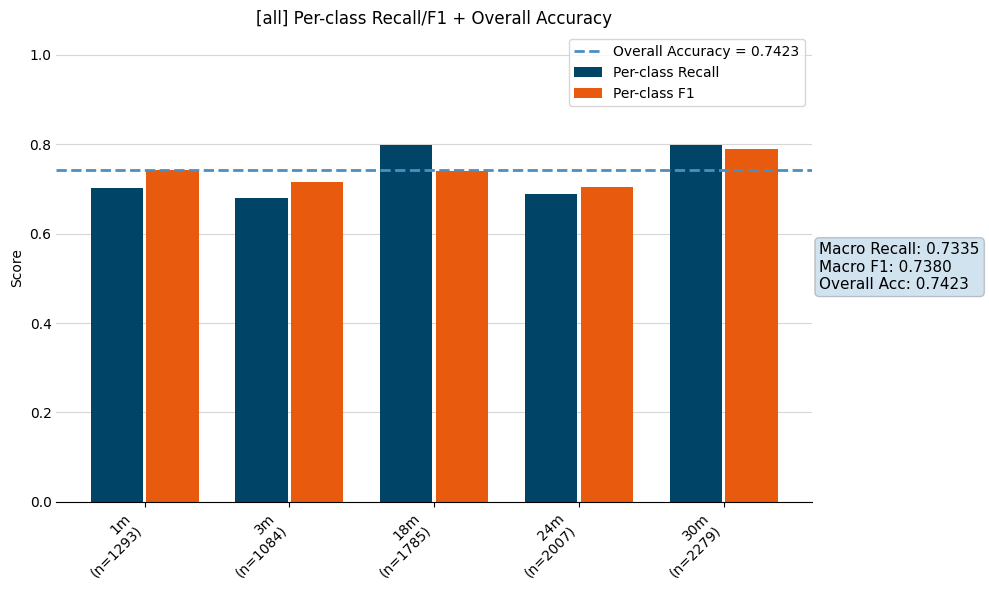

Saved metrics figure to: /content/qwen3_bladder_tpu_out/final_all_metrics.png


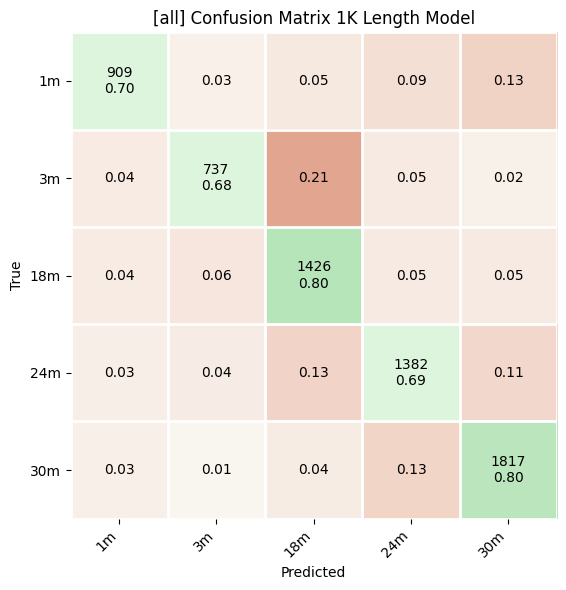

Saved confusion matrix figure to: /content/qwen3_bladder_tpu_out/final_all_confusion_matrix.png

[WARN] Could not map 'brain' back to validation indices; running predict() for this split.



=== Split: brain (n=1664) ===
Accuracy: 0.677885 | Macro-F1: 0.404186


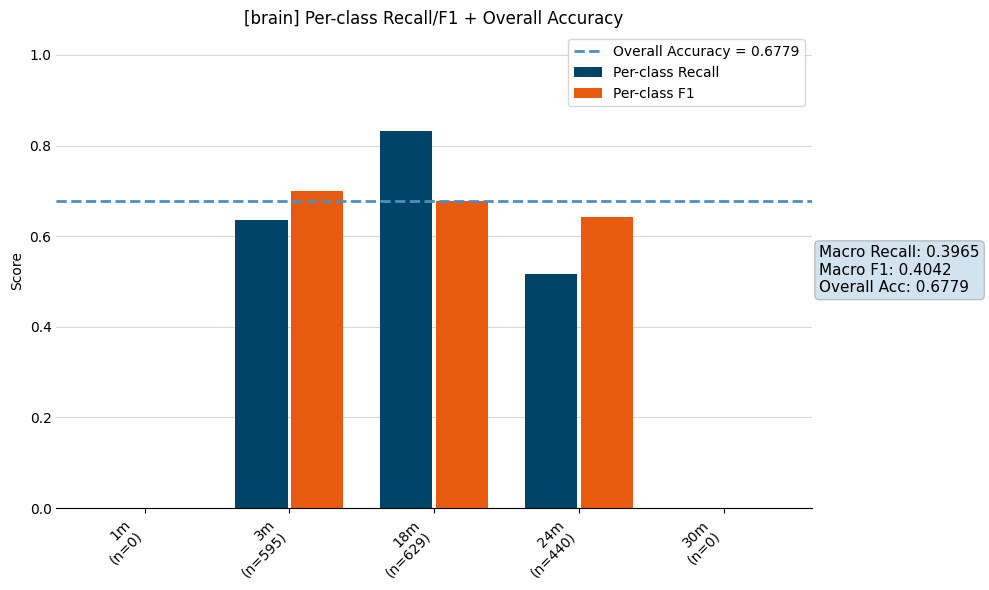

Saved metrics figure to: /content/qwen3_bladder_tpu_out/final_brain_metrics.png


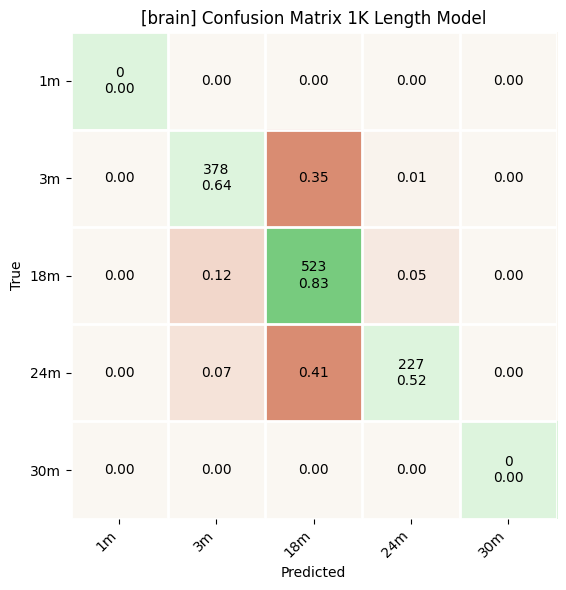

Saved confusion matrix figure to: /content/qwen3_bladder_tpu_out/final_brain_confusion_matrix.png

[WARN] Could not map 'bladder' back to validation indices; running predict() for this split.



=== Split: bladder (n=640) ===
Accuracy: 0.776563 | Macro-F1: 0.604861


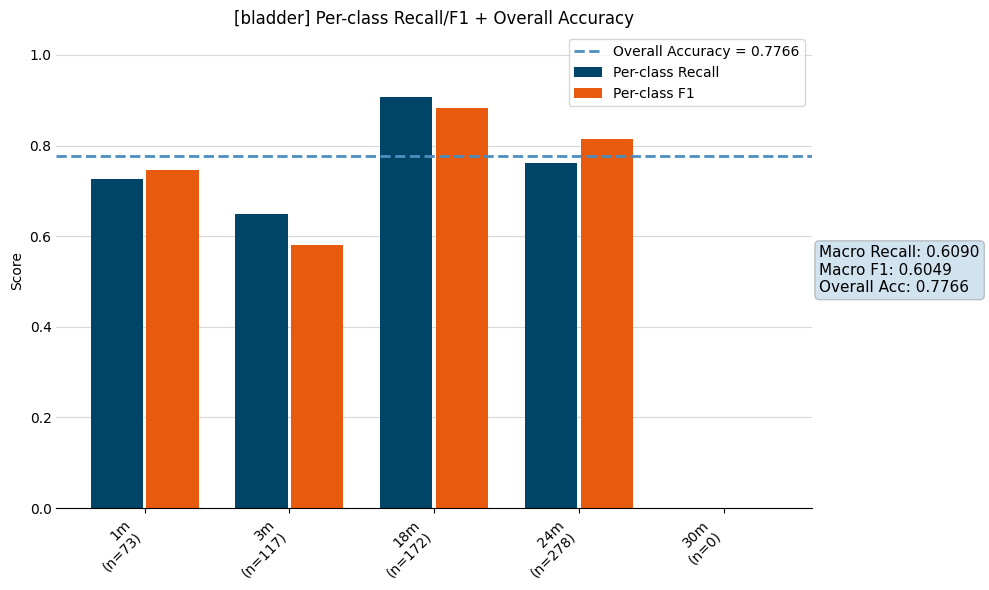

Saved metrics figure to: /content/qwen3_bladder_tpu_out/final_bladder_metrics.png


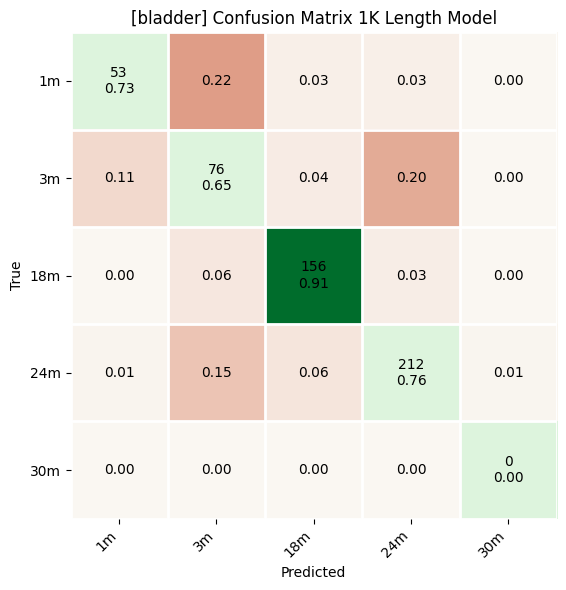

Saved confusion matrix figure to: /content/qwen3_bladder_tpu_out/final_bladder_confusion_matrix.png

[WARN] Could not map 'bone' back to validation indices; running predict() for this split.



=== Split: bone (n=2176) ===
Accuracy: 0.707721 | Macro-F1: 0.522889


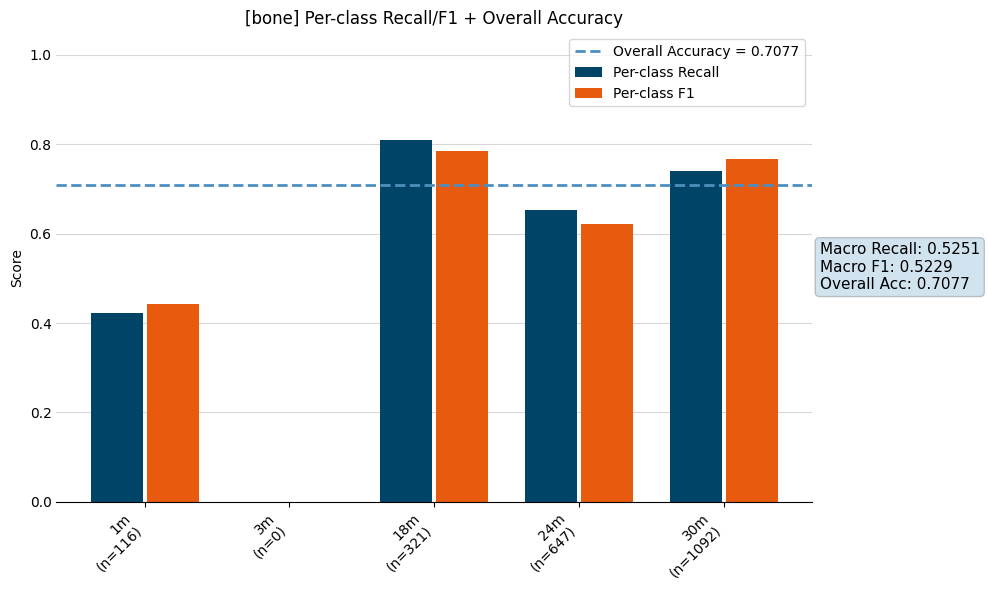

Saved metrics figure to: /content/qwen3_bladder_tpu_out/final_bone_metrics.png


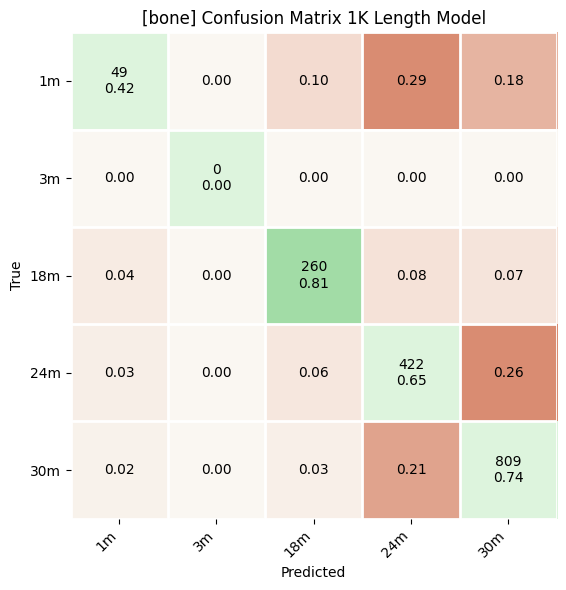

Saved confusion matrix figure to: /content/qwen3_bladder_tpu_out/final_bone_confusion_matrix.png

[WARN] Could not map 'limb' back to validation indices; running predict() for this split.



=== Split: limb (n=1536) ===
Accuracy: 0.867839 | Macro-F1: 0.689082


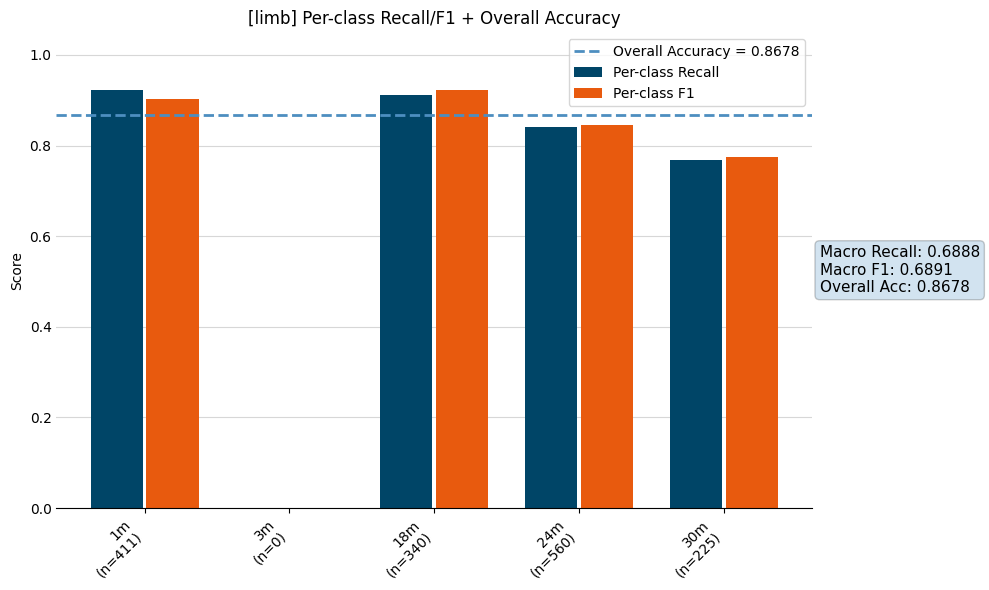

Saved metrics figure to: /content/qwen3_bladder_tpu_out/final_limb_metrics.png


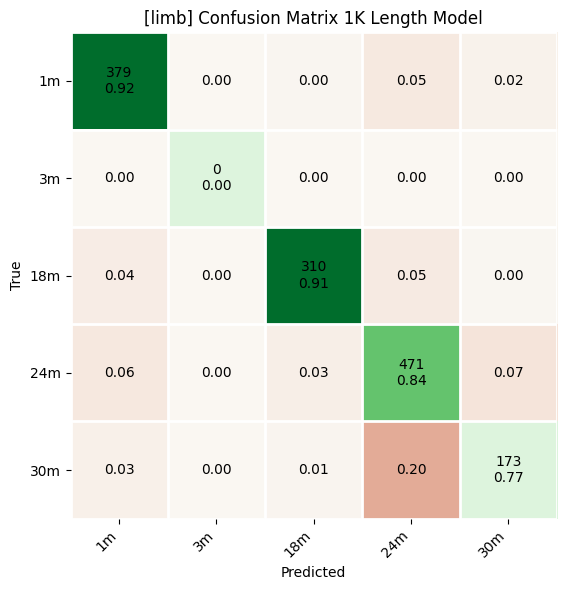

Saved confusion matrix figure to: /content/qwen3_bladder_tpu_out/final_limb_confusion_matrix.png

[WARN] Could not map 'kidney' back to validation indices; running predict() for this split.



=== Split: kidney (n=640) ===
Accuracy: 0.764062 | Macro-F1: 0.632413


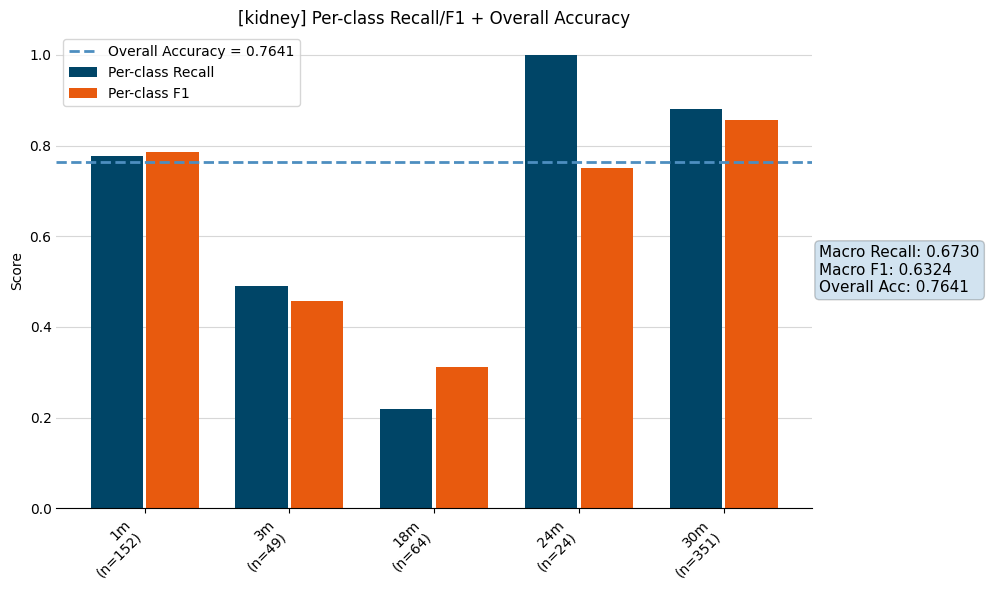

Saved metrics figure to: /content/qwen3_bladder_tpu_out/final_kidney_metrics.png


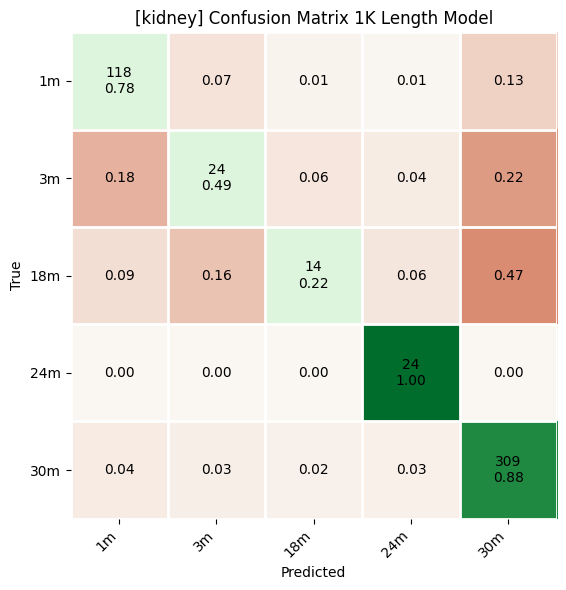

Saved confusion matrix figure to: /content/qwen3_bladder_tpu_out/final_kidney_confusion_matrix.png

[WARN] Could not map 'liver' back to validation indices; running predict() for this split.



=== Split: liver (n=256) ===
Accuracy: 0.726562 | Macro-F1: 0.269957


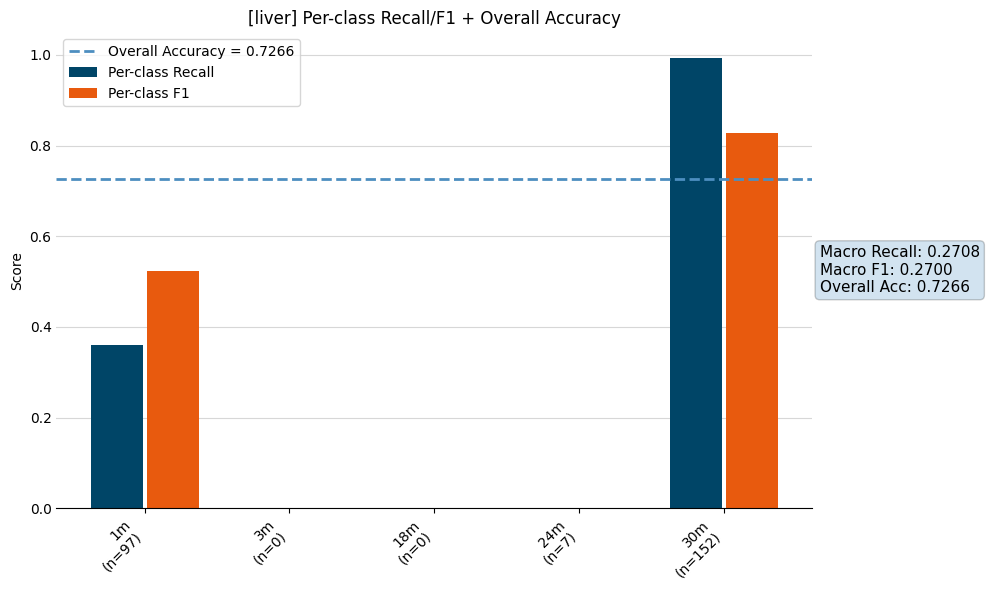

Saved metrics figure to: /content/qwen3_bladder_tpu_out/final_liver_metrics.png


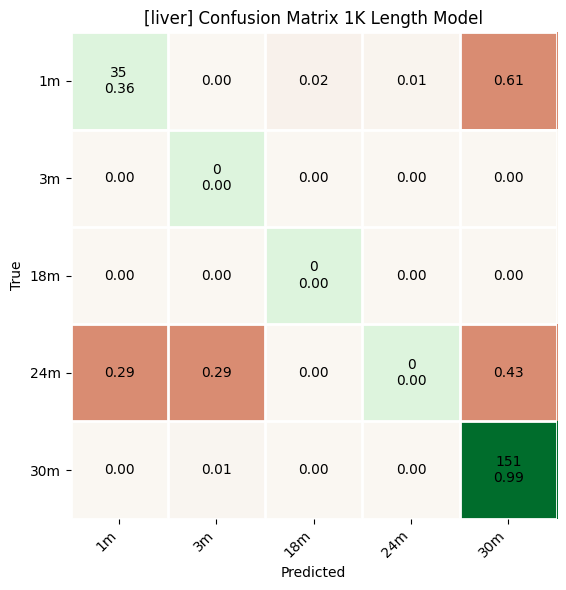

Saved confusion matrix figure to: /content/qwen3_bladder_tpu_out/final_liver_confusion_matrix.png

[WARN] Could not map 'lung' back to validation indices; running predict() for this split.



=== Split: lung (n=768) ===
Accuracy: 0.699219 | Macro-F1: 0.570106


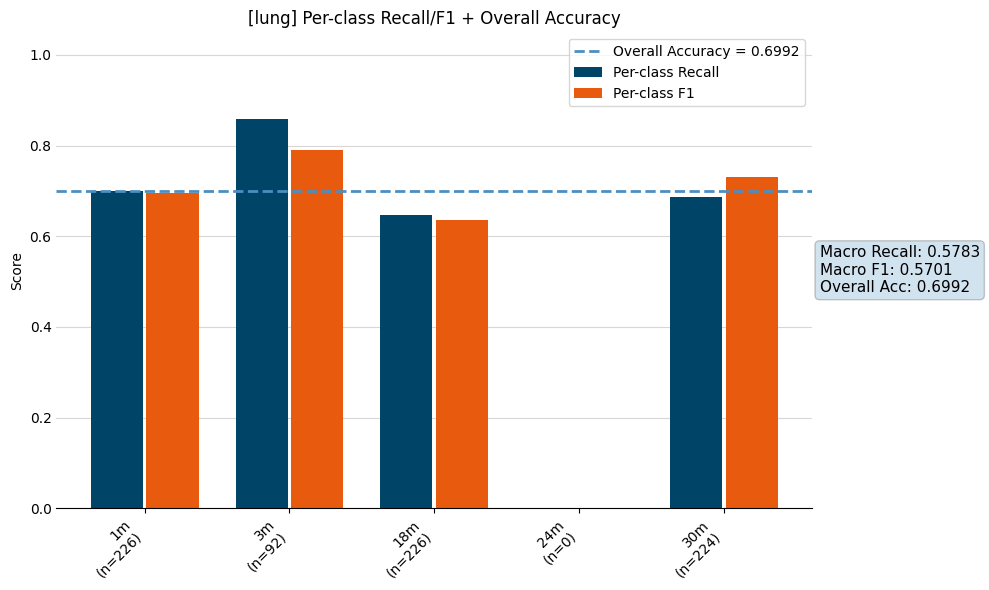

Saved metrics figure to: /content/qwen3_bladder_tpu_out/final_lung_metrics.png


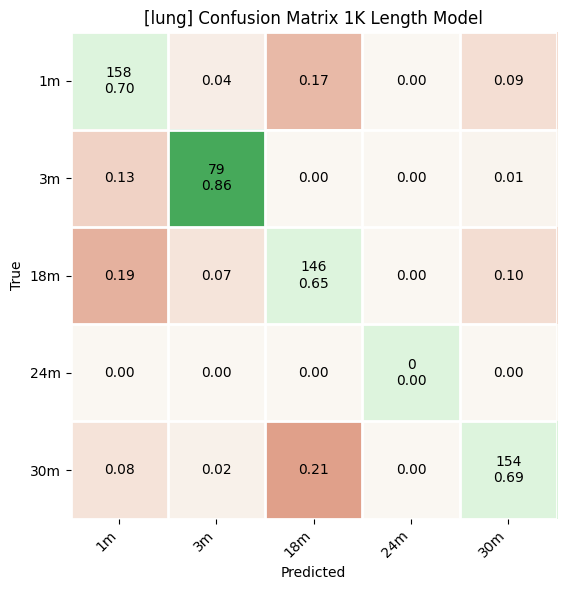

Saved confusion matrix figure to: /content/qwen3_bladder_tpu_out/final_lung_confusion_matrix.png

[WARN] Could not map 'heart' back to validation indices; running predict() for this split.



=== Split: heart (n=384) ===
Accuracy: 0.843750 | Macro-F1: 0.529815


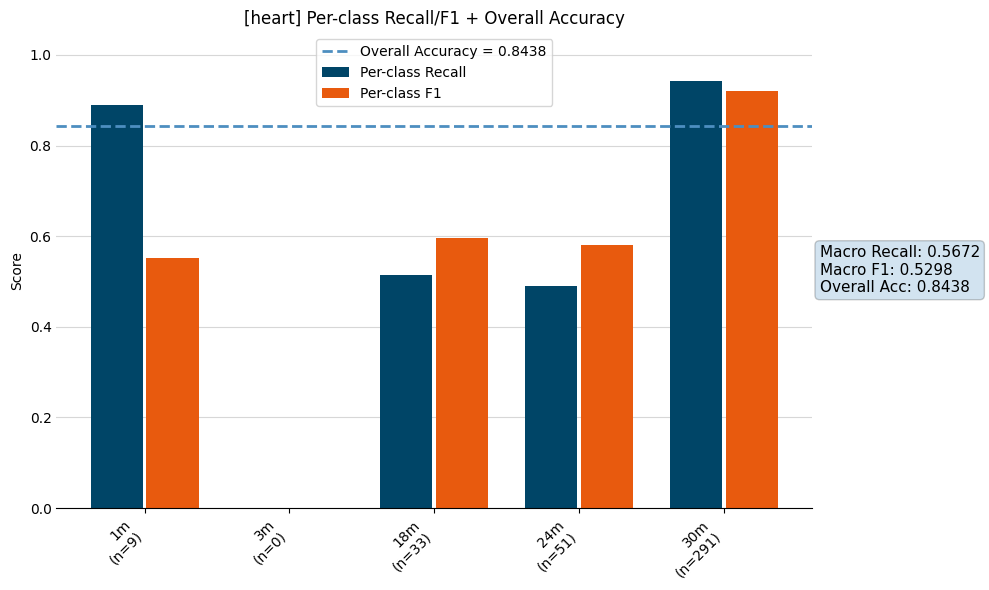

Saved metrics figure to: /content/qwen3_bladder_tpu_out/final_heart_metrics.png


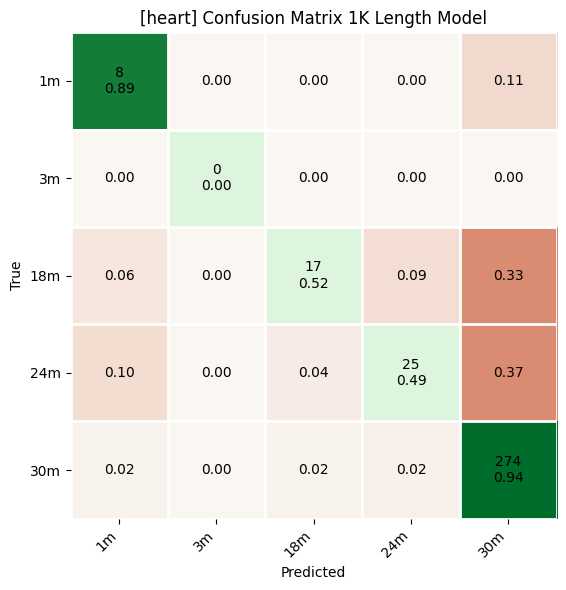

Saved confusion matrix figure to: /content/qwen3_bladder_tpu_out/final_heart_confusion_matrix.png

Saved/updated detailed eval JSON to: /content/qwen3_bladder_tpu_out/final_eval_details_by_split.json


/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:356: UserWarning: Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.
  warnings.warn("Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.")


Saved model + tokenizer to: /content/qwen3_bladder_tpu_out

===== Summary (all + subcategories) =====
       all | n=  8448 | accuracy=0.742306 | macro_f1=0.738041
     brain | n=  1664 | accuracy=0.677885 | macro_f1=0.404186
   bladder | n=   640 | accuracy=0.776563 | macro_f1=0.604861
      bone | n=  2176 | accuracy=0.707721 | macro_f1=0.522889
      limb | n=  1536 | accuracy=0.867839 | macro_f1=0.689082
    kidney | n=   640 | accuracy=0.764062 | macro_f1=0.632413
     liver | n=   256 | accuracy=0.726562 | macro_f1=0.269957
      lung | n=   768 | accuracy=0.699219 | macro_f1=0.570106
     heart | n=   384 | accuracy=0.843750 | macro_f1=0.529815

===== Per-Category Accuracy by Organ =====

--- BRAIN ---
  1m: N/A (no samples)
  3m: 0.6353
  18m: 0.8315
  24m: 0.5159
  30m: N/A (no samples)

--- BLADDER ---
  1m: 0.7260
  3m: 0.6496
  18m: 0.9070
  24m: 0.7626
  30m: N/A (no samples)

--- BONE ---
  1m: 0.4224
  3m: N/A (no samples)
  18m: 0.8100
  24m: 0.6522
  30m: 0.7408

--- L

In [17]:
validation_ds = tok["validation"]
pred_out_val = trainer.predict(validation_ds, metric_key_prefix="final_all")
logits_val = _get_logits(pred_out_val.predictions)
y_true_val = np.asarray(pred_out_val.label_ids).reshape(-1)
metrics_val = getattr(pred_out_val, "metrics", {}) or {}

res_all = evaluate_from_arrays("all", y_true_val, logits_val, metrics=metrics_val)

print("\n==============================")
print("=== Final overall metrics: all ===")
print("==============================")
for key, value in res_all["overall_metrics"].items():
    if isinstance(value, (int, float)):
        print(f"{key}: {value:.6f}")
    else:
        print(f"{key}: {value}")

print("\n=== Per-label accuracy (row-wise / recall): all ===")
for name in label_names:
    value = res_all["per_label_accuracy_rowwise"][name]
    print(f"{name}: {value:.4f}" if np.isfinite(value) else f"{name}: nan (no samples)")

print("\n=== Confusion matrix (rows=true, cols=pred): all ===")
print("labels:", label_names)
print(np.array(res_all["confusion_matrix"]["matrix"], dtype=np.int64))

plot_accuracy_f1_recall(res_all, out_dir)
plot_confusion_matrix(res_all, out_dir)

subcategory_keys = [key for key in tok.keys() if key not in ("train", "validation")]
results = {"all": res_all}

for split_name in subcategory_keys:
    subset_ds = tok[split_name]
    idx = get_subset_indices_in_validation(subset_ds, validation_ds)

    if idx is None:
        print(f"\n[WARN] Could not map '{split_name}' back to validation indices; running predict() for this split.")
        pred_out_sub = trainer.predict(subset_ds, metric_key_prefix=f"final_{split_name}")
        logits_sub = _get_logits(pred_out_sub.predictions)
        y_true_sub = np.asarray(pred_out_sub.label_ids).reshape(-1)
        metrics_sub = getattr(pred_out_sub, "metrics", {}) or {}
        res_sub = evaluate_from_arrays(split_name, y_true_sub, logits_sub, metrics=metrics_sub)
    else:
        idx = np.asarray(idx, dtype=np.int64)
        logits_sub = logits_val[idx]
        y_true_sub = y_true_val[idx]
        res_sub = evaluate_from_arrays(split_name, y_true_sub, logits_sub, metrics=None)

    results[split_name] = res_sub

    print("\n==============================")
    print(f"=== Split: {split_name} (n={res_sub['num_samples']}) ===")
    print(f"Accuracy: {res_sub['derived_metrics']['accuracy']:.6f} | Macro-F1: {res_sub['derived_metrics']['macro_f1']:.6f}")
    print("==============================")

    plot_accuracy_f1_recall(res_sub, out_dir)
    plot_confusion_matrix(res_sub, out_dir)

os.makedirs(out_dir, exist_ok=True)
details_path = os.path.join(out_dir, "final_eval_details_by_split.json")
with open(details_path, "w") as handle:
    json.dump(results, handle, indent=2)
print(f"\nSaved/updated detailed eval JSON to: {details_path}")

try:
    is_master = xm.is_master_ordinal()
except Exception:
    is_master = True

if is_master:
    trainer.save_model(out_dir)
    tokenizer.save_pretrained(out_dir)
    print(f"Saved model + tokenizer to: {out_dir}")

print("\n===== Summary (all + subcategories) =====")
for key in ["all"] + subcategory_keys:
    acc = results[key]["derived_metrics"]["accuracy"]
    mf1 = results[key]["derived_metrics"]["macro_f1"]
    n = results[key]["num_samples"]
    print(f"{key:>10s} | n={n:6d} | accuracy={acc:.6f} | macro_f1={mf1:.6f}")

print("\n===== Per-Category Accuracy by Organ =====")
for split_name, res in results.items():
    if split_name == "all":
        continue
    print(f"\n--- {split_name.upper()} ---")
    for label, acc in res.get("per_label_accuracy_rowwise", {}).items():
        print(f"  {label}: {acc:.4f}" if np.isfinite(acc) else f"  {label}: N/A (no samples)")


## 8. Optional Runtime Cleanup


In [ ]:
# Uncomment when finished if you want Colab to release the runtime.
# from google.colab import runtime
# runtime.unassign()
